# Exploration Results

## Learning Curves

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import re
import subprocess

Paths to drive folders

In [3]:
EPSILON_GREEDY_DIR = '/content/drive/MyDrive/Exploration/Breakout/EpsilonGreedy/'
BOLTZMANN_DIR      = '/content/drive/MyDrive/Exploration/Breakout/Boltzmann/'
ENTROPY_DIR        = '/content/drive/MyDrive/Exploration/Breakout/EntropyReg/'
UCB_DIR            = '/content/drive/MyDrive/Exploration/Breakout/UCB/'
THOMPSON_DIR       = '/content/drive/MyDrive/Exploration/Breakout/Thompson/'
RND_DIR            = '/content/drive/MyDrive/Exploration/Breakout/RND/'

experiments = [
    ("Epsilon Greedy", EPSILON_GREEDY_DIR),
    ("Boltzmann", BOLTZMANN_DIR),
    ("Entropy Reg", ENTROPY_DIR),
    ("UCB", UCB_DIR),
    ("Thompson", THOMPSON_DIR),
    ("RND", RND_DIR),
]

Helper functions

In [4]:
def load_log(path):
    records = []

    with open(path) as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            # Extract ALL JSON objects from the line
            matches = re.findall(r'\{.*?\}', line)

            for m in matches:
                try:
                    records.append(json.loads(m))
                except:
                    continue

    # If nothing loaded
    if len(records) == 0:
        print(f"WARNING: no valid records in {path}")
        return np.array([]), np.array([]), np.array([]), np.array([])

    # Safely extract fields and skip bad records
    def safe_get(key):
        return np.array([r[key] for r in records if key in r])

    episodes    = safe_get("episode")
    total_steps = safe_get("total_steps")
    rewards     = safe_get("reward")
    ep_lens     = safe_get("ep_len")

    # Ensure same length
    min_len = min(len(episodes), len(total_steps), len(rewards), len(ep_lens))
    
    return (
        episodes[:min_len],
        total_steps[:min_len],
        rewards[:min_len],
        ep_lens[:min_len],
    )

def smooth(values, window=100):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

def align_and_stack(list_of_arrays):
    """Trim all arrays to shortest length and stack"""
    min_len = min(len(arr) for arr in list_of_arrays)
    return np.stack([arr[:min_len] for arr in list_of_arrays])

Plot learning curves

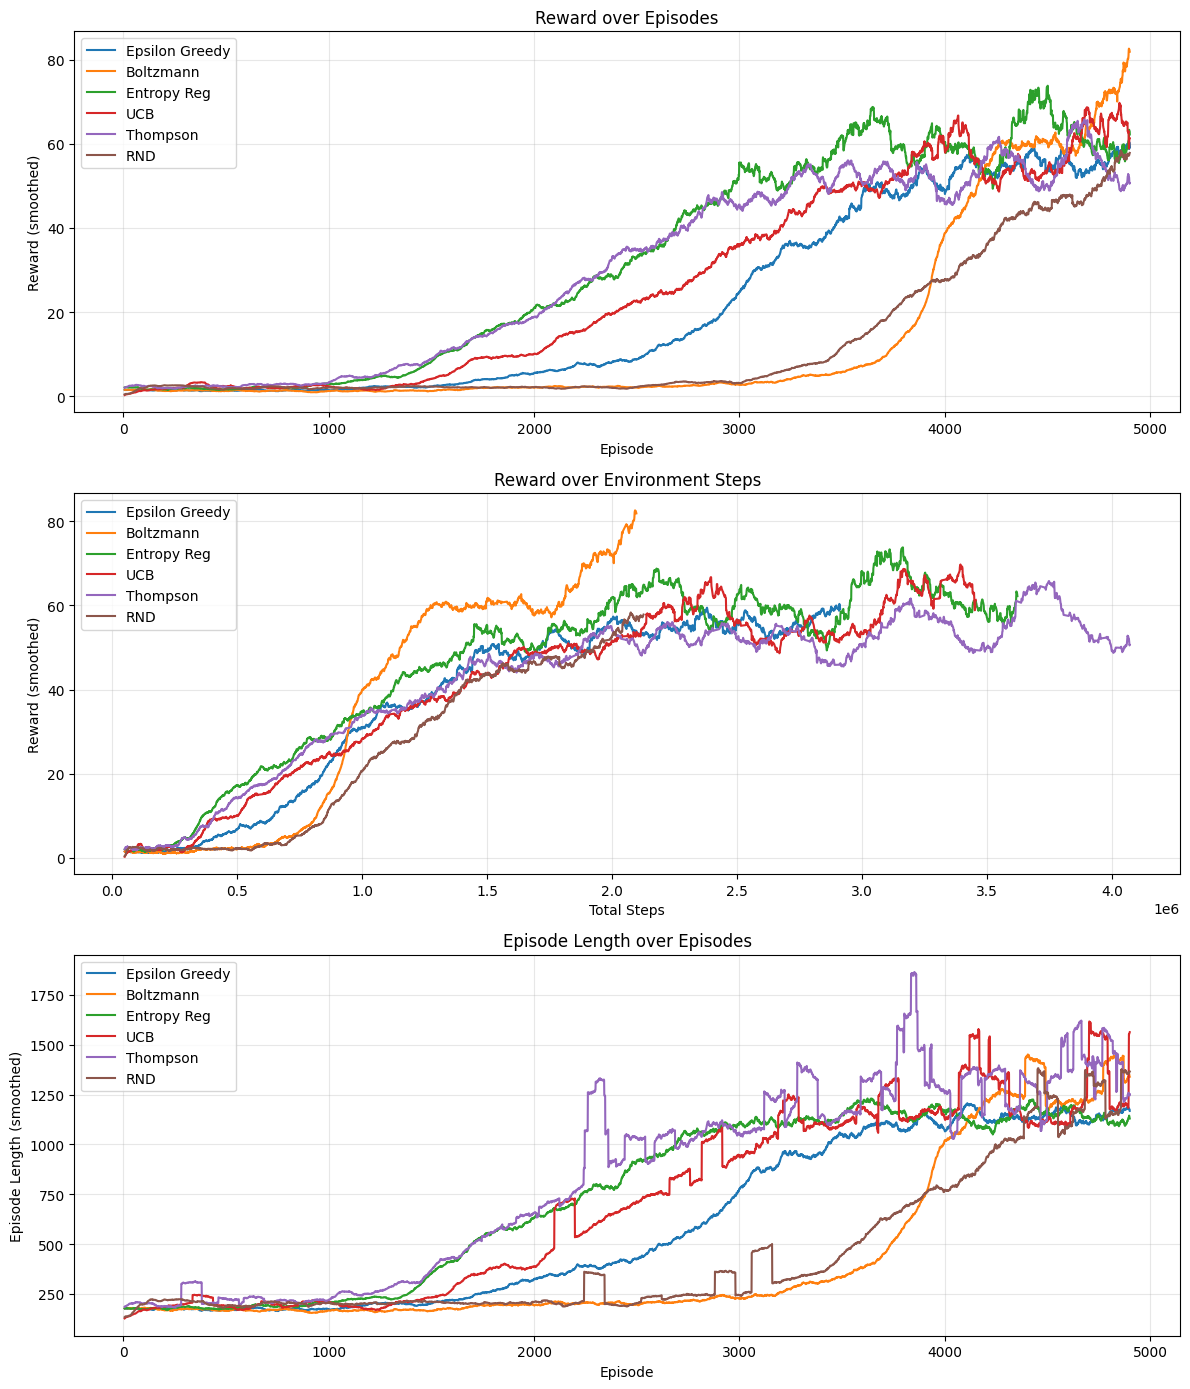

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
ax_rew_ep, ax_rew_step, ax_len_ep = axes

for label, directory in experiments:
    log_files = sorted(glob.glob(os.path.join(directory, '*.jsonl')))

    all_rewards = []
    all_ep_lens = []
    all_steps   = []
    all_episodes = None

    for path in log_files:
        episodes, total_steps, rewards, ep_lens = load_log(path)
        
        episodes     = episodes[5:]
        total_steps  = total_steps[5:]
        rewards      = rewards[5:]
        ep_lens      = ep_lens[5:]

        s_rewards = smooth(rewards)
        s_ep_lens = smooth(ep_lens)

        ep_trim   = episodes[:len(s_rewards)]
        step_trim = total_steps[:len(s_rewards)]

        all_rewards.append(s_rewards)
        all_ep_lens.append(s_ep_lens)
        all_steps.append(step_trim)

        if all_episodes is None:
            all_episodes = ep_trim[:len(s_rewards)]

    if len(all_rewards) == 0:
        continue

    # Stack runs
    rewards_stack = align_and_stack(all_rewards)
    ep_lens_stack = align_and_stack(all_ep_lens)
    steps_stack   = align_and_stack(all_steps)

    # Mean + std
    rew_mean = rewards_stack.mean(axis=0)
    rew_std  = rewards_stack.std(axis=0)

    len_mean = ep_lens_stack.mean(axis=0)
    len_std  = ep_lens_stack.std(axis=0)

    steps_mean = steps_stack.mean(axis=0)

    # Reward vs Episodes
    ax_rew_ep.plot(all_episodes[:len(rew_mean)], rew_mean, label=label)
    ax_rew_ep.fill_between(
        all_episodes[:len(rew_mean)],
        rew_mean - rew_std,
        rew_mean + rew_std,
        alpha=0.2
    )

    # Reward vs Steps
    ax_rew_step.plot(steps_mean, rew_mean, label=label)
    ax_rew_step.fill_between(
        steps_mean,
        rew_mean - rew_std,
        rew_mean + rew_std,
        alpha=0.2
    )

    # Episode Length vs Episodes
    ax_len_ep.plot(all_episodes[:len(len_mean)], len_mean, label=label)
    ax_len_ep.fill_between(
        all_episodes[:len(len_mean)],
        len_mean - len_std,
        len_mean + len_std,
        alpha=0.2
    )

ax_rew_ep.set_title("Reward over Episodes")
ax_rew_ep.set_xlabel("Episode")
ax_rew_ep.set_ylabel("Reward (smoothed)")
ax_rew_ep.grid(True, alpha=0.3)

ax_rew_step.set_title("Reward over Environment Steps")
ax_rew_step.set_xlabel("Total Steps")
ax_rew_step.set_ylabel("Reward (smoothed)")
ax_rew_step.grid(True, alpha=0.3)

ax_len_ep.set_title("Episode Length over Episodes")
ax_len_ep.set_xlabel("Episode")
ax_len_ep.set_ylabel("Episode Length (smoothed)")
ax_len_ep.grid(True, alpha=0.3)

# Clean legends
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.show()

## Test Evaluation

In [ ]:
!git clone https://github.com/benatfroemming/exploration.git
%cd exploration
!pip install -r requirements.txt

In [7]:
def find_pth(directory: str) -> str:
    matches = glob.glob(os.path.join(directory, "**", "*.pth"), recursive=True)
    if not matches:
        raise FileNotFoundError(f"No .pth file found in {directory}")
    return matches[0]

epsilon_greedy_policy = find_pth(EPSILON_GREEDY_DIR)
boltzmann_policy      = find_pth(BOLTZMANN_DIR)
entropy_policy        = find_pth(ENTROPY_DIR)
ucb_policy       = find_pth(UCB_DIR)
thompson_policy       = find_pth(THOMPSON_DIR)
rnd_policy            = find_pth(RND_DIR)

STRATEGY_MAP = {
    epsilon_greedy_policy: "epsilon_greedy",
    boltzmann_policy:      "boltzmann",
    entropy_policy:        "entropy_reg",
    ucb_policy:            "ucb",
    thompson_policy:       "thompson",
    rnd_policy:            "rnd",
}

In [9]:
def run_eval(policy_path: str, strategy: str, episodes: int = 10) -> None:
    result = subprocess.run(
        ["python", "eval.py", "--policy", policy_path, "--strategy", strategy, "--episodes", str(episodes)],
        capture_output=True,
        text=True,
    )
    print(result.stdout)    
    print(f"\n{'-' * 50}")

for policy, strategy in STRATEGY_MAP.items():
    run_eval(policy, strategy)

Device   : cuda
Policy   : /content/drive/MyDrive/Exploration/Breakout/EpsilonGreedy/dqn_ALE-Breakout-v5_epsilon_greedy_final.pth
Env      : ALE/Breakout-v5
Strategy : epsilon_greedy
Episodes : 10

Loading checkpoint: /content/drive/MyDrive/Exploration/Breakout/EpsilonGreedy/dqn_ALE-Breakout-v5_epsilon_greedy_final.pth
Total reward : 214.0
Average      : 21.40 ± 13.40
Min / Max    : 4.0 / 41.0

STDERR: A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


--------------------------------------------------
Device   : cuda
Policy   : /content/drive/MyDrive/Exploration/Breakout/Boltzmann/dqn_ALE-Breakout-v5_boltzmann_final.pth
Env      : ALE/Breakout-v5
Strategy : boltzmann
Episodes : 10

Loading checkpoint: /content/drive/MyDrive/Exploration/Breakout/Boltzmann/dqn_ALE-Breakout-v5_boltzmann_final.pth
Total reward : 339.0
Average      : 33.90 ± 38.05
Min / Max    : 5.0 / 117.0

STDERR: A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stell